### Data Preprocessing
#### Used Car Price Prediction — ML Training Pipeline
**Justin King Bais | University of Mindanao**

This notebook covers the complete data preprocessing pipeline:
- Dataset loading and exploration
- Missing value handling
- Outlier treatment (IQR method)
- Feature engineering
- Label encoding
- Feature scaling
- Train/test split
- Export preprocessed data for model training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import json
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'serif'

### 1. Load Dataset

In [2]:
df_raw = pd.read_csv('Used_Car_Price_Prediction.csv')

print(f"Dataset loaded successfully.")
print(f"Shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}")
df_raw.head()

Dataset loaded successfully.
Shape: (7400, 29)
Rows: 7,400 | Columns: 29


,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False


### 2. Exploratory Data Analysis

Before preprocessing, we explore the dataset to understand its structure,
data types, and identify quality issues.

In [4]:

print("=== Column Data Types ===")
print(df_raw.dtypes)

=== Column Data Types ===
car_name                object
yr_mfr                   int64
fuel_type               object
kms_run                  int64
sale_price               int64
city                    object
times_viewed             int64
body_type               object
transmission            object
variant                 object
assured_buy               bool
registered_city         object
registered_state        object
is_hot                    bool
rto                     object
source                  object
make                    object
model                   object
car_availability        object
total_owners             int64
broker_quote             int64
original_price         float64
car_rating              object
ad_created_on           object
fitness_certificate     object
emi_starts_from          int64
booking_down_pymnt       int64
reserved                  bool
warranty_avail            bool
dtype: object


In [5]:
print("=== Statistical Summary ===")
df_raw.describe()

=== Statistical Summary ===


,yr_mfr,kms_run,sale_price,times_viewed,total_owners,broker_quote,original_price,emi_starts_from,booking_down_pymnt
count,7400.000000,7400.000000,7.400000e+03,7400.000000,7400.000000,7.400000e+03,4.120000e+03,7400.000000,7400.000000
mean,2013.885676,62624.520000,4.548892e+05,1550.706081,1.327297,4.322044e+05,5.510351e+05,10565.942027,68233.529054
std,3.087613,43532.042371,2.827023e+05,2080.952842,0.579798,2.880316e+05,3.119887e+05,6566.468434,42405.389468
min,1996.000000,60.000000,0.000000e+00,3.000000,1.000000,0.000000e+00,9.689900e+04,0.000000,0.000000
25%,2012.000000,31885.250000,2.811740e+05,554.750000,1.000000,2.526612e+05,3.414930e+05,6531.250000,42176.250000
50%,2014.000000,55765.000000,3.824490e+05,1088.000000,1.000000,3.611445e+05,4.674800e+05,8883.000000,57367.500000
75%,2016.000000,84184.000000,5.401490e+05,1926.500000,2.000000,5.260180e+05,6.675258e+05,12546.250000,81022.500000
max,2021.000000,996609.000000,3.866000e+06,61930.000000,6.000000,3.250000e+06,2.765057e+06,89798.000000,579901.000000


In [6]:
# Missing value analysis
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("=== Missing Values per Column ===")
print(missing)
print(f"\nTotal columns with missing values: {len(missing)}")
print(f"Total missing entries: {missing.sum():,}")

=== Missing Values per Column ===
original_price         3280
car_availability        620
transmission            556
source                  126
body_type               103
registered_state         10
registered_city          10
car_rating                9
fitness_certificate       8
ad_created_on             1
dtype: int64

Total columns with missing values: 10
Total missing entries: 4,723


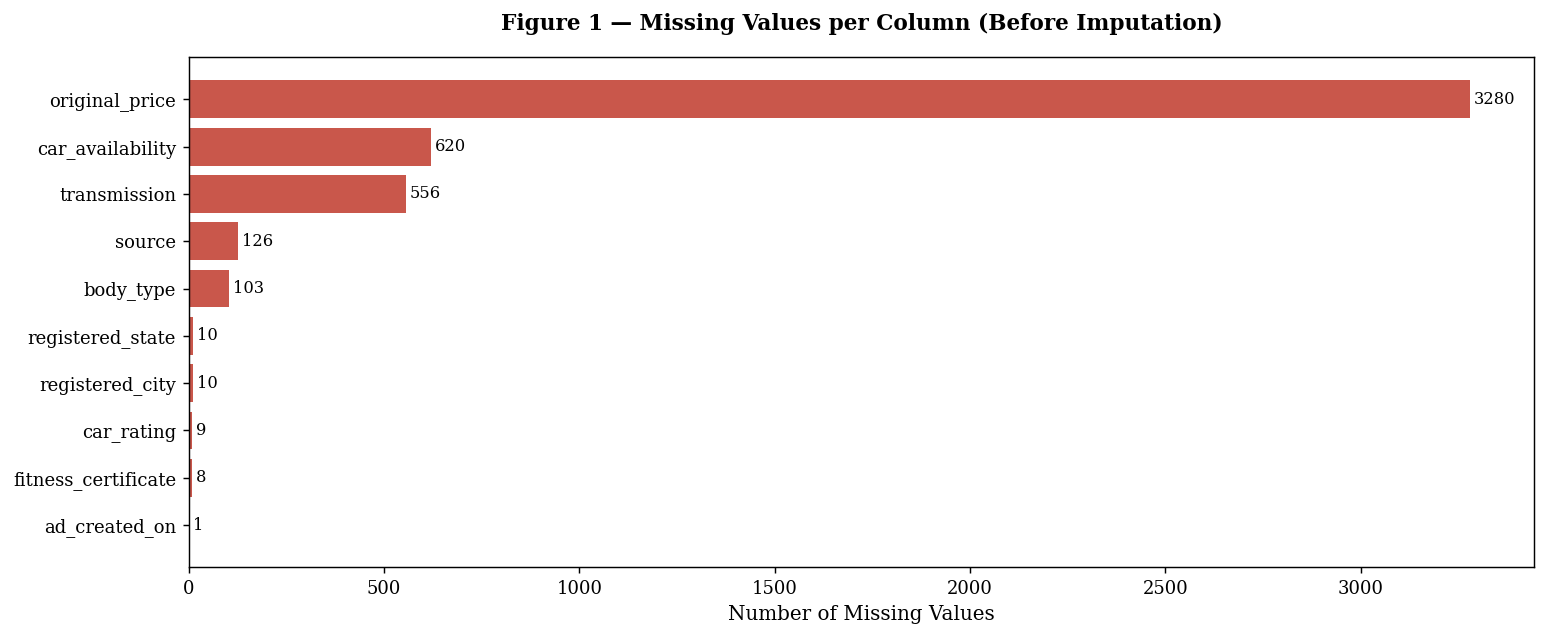

Saved: fig1_missing_values.png


In [7]:
# Figure 1 — Missing values bar chart
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(missing.index, missing.values,
               color='#c0392b', edgecolor='none', alpha=0.85)
ax.set_xlabel('Number of Missing Values', fontsize=11)
ax.set_title('Figure 1 — Missing Values per Column (Before Imputation)',
             fontsize=12, fontweight='bold', pad=15)
for bar, val in zip(bars, missing.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig1_missing_values.png', bbox_inches='tight')
plt.show()
print("Saved: fig1_missing_values.png")

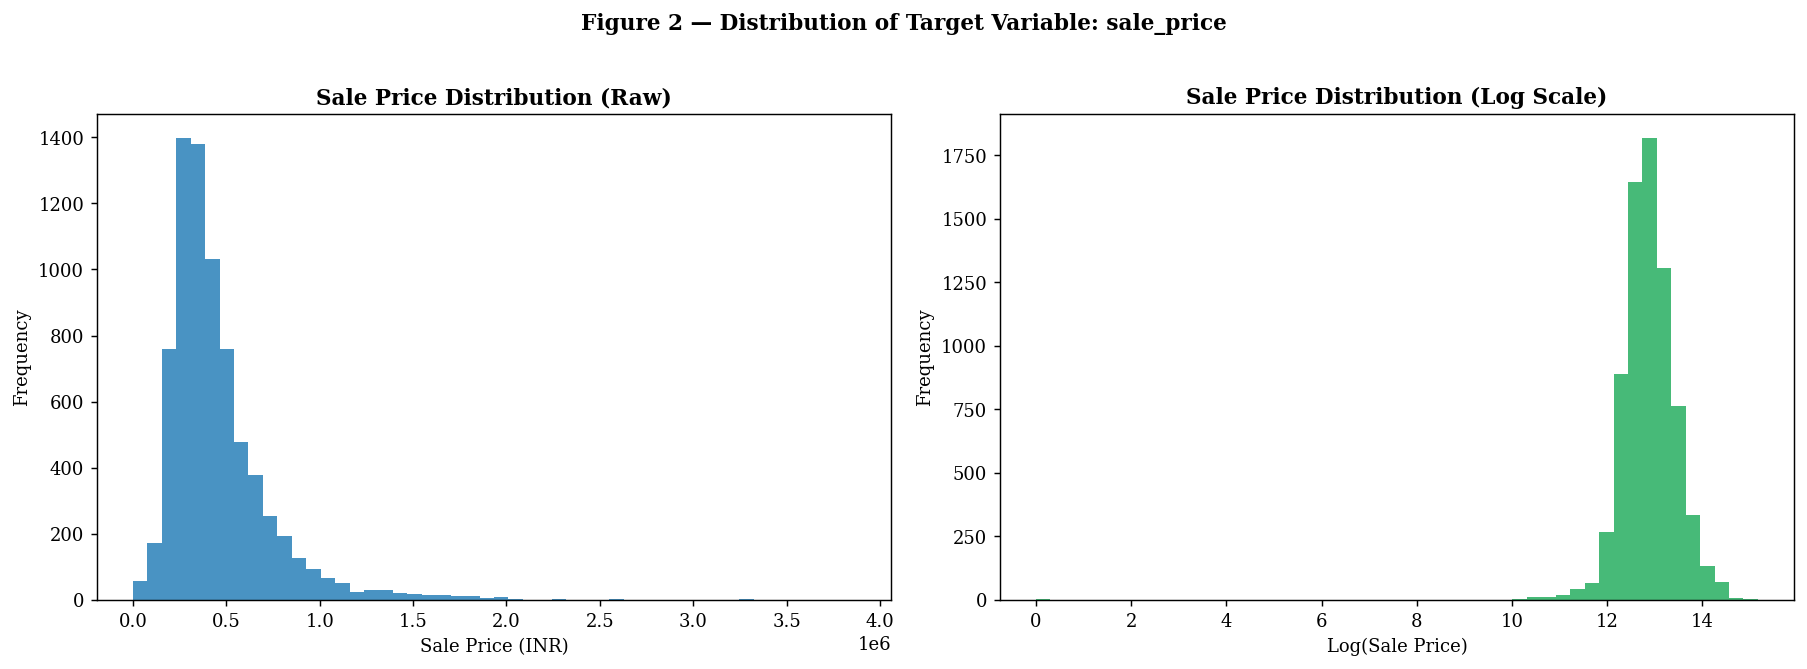

sale_price stats:
  Mean   : INR 454,889
  Median : INR 382,449
  Min    : INR 0
  Max    : INR 3,866,000


In [8]:
# Figure 2 — Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['sale_price'].dropna(), bins=50,
             color='#2980b9', edgecolor='none', alpha=0.85)
axes[0].set_title('Sale Price Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Sale Price (INR)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df_raw['sale_price'].dropna()), bins=50,
             color='#27ae60', edgecolor='none', alpha=0.85)
axes[1].set_title('Sale Price Distribution (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Frequency')

fig.suptitle('Figure 2 — Distribution of Target Variable: sale_price',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_sale_price_dist.png', bbox_inches='tight')
plt.show()

print(f"sale_price stats:")
print(f"  Mean   : INR {df_raw['sale_price'].mean():,.0f}")
print(f"  Median : INR {df_raw['sale_price'].median():,.0f}")
print(f"  Min    : INR {df_raw['sale_price'].min():,.0f}")
print(f"  Max    : INR {df_raw['sale_price'].max():,.0f}")

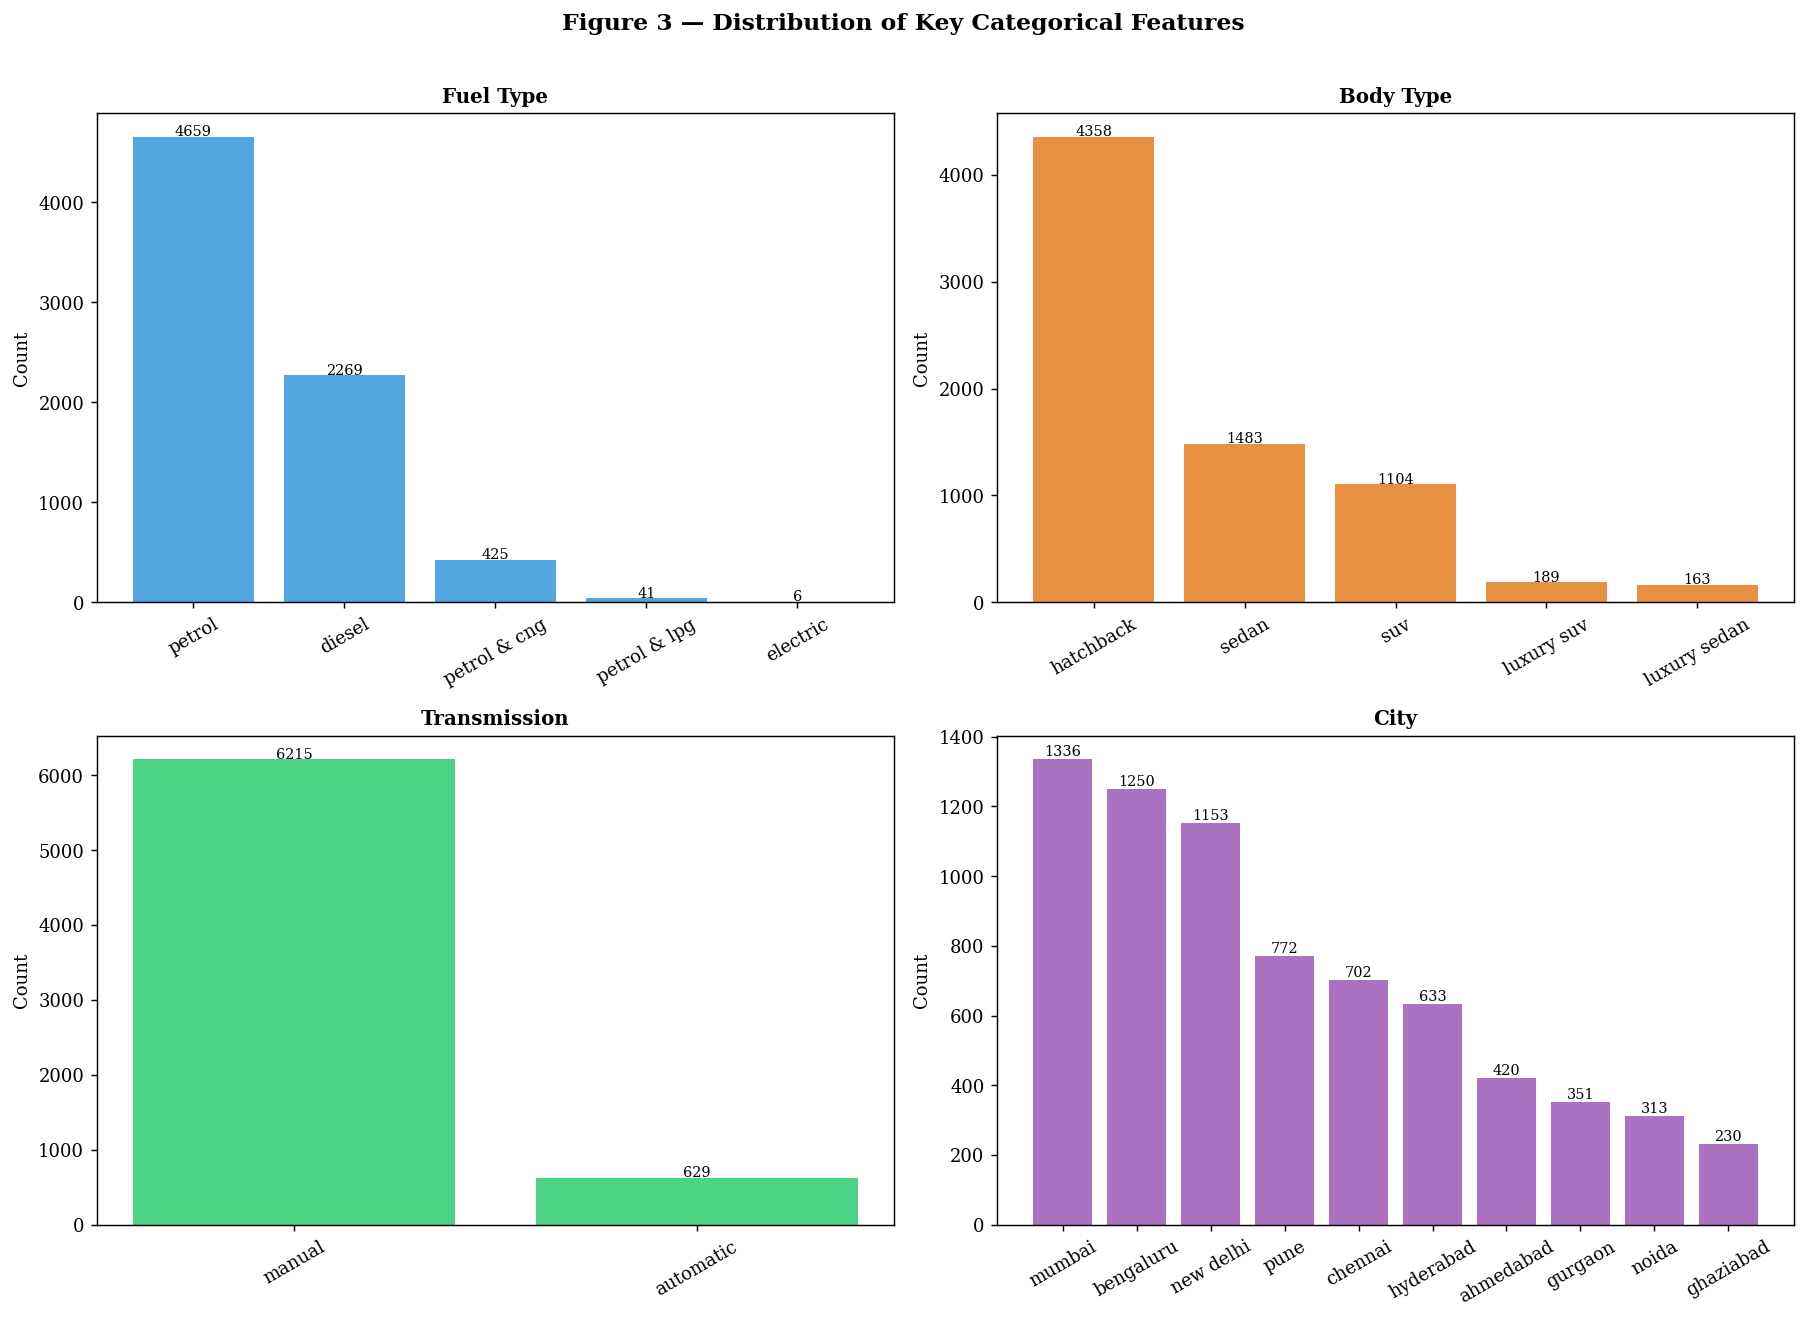

In [9]:
# Figure 3 — Categorical feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cats = [('fuel_type', 'Fuel Type'),
        ('body_type', 'Body Type'),
        ('transmission', 'Transmission'),
        ('city', 'City')]
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for ax, (col, label), color in zip(axes.flatten(), cats, colors):
    counts = df_raw[col].value_counts().head(10)
    ax.bar(counts.index, counts.values, color=color,
           edgecolor='none', alpha=0.85)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontsize=8)

fig.suptitle('Figure 3 — Distribution of Key Categorical Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_categorical_dist.png', bbox_inches='tight')
plt.show()

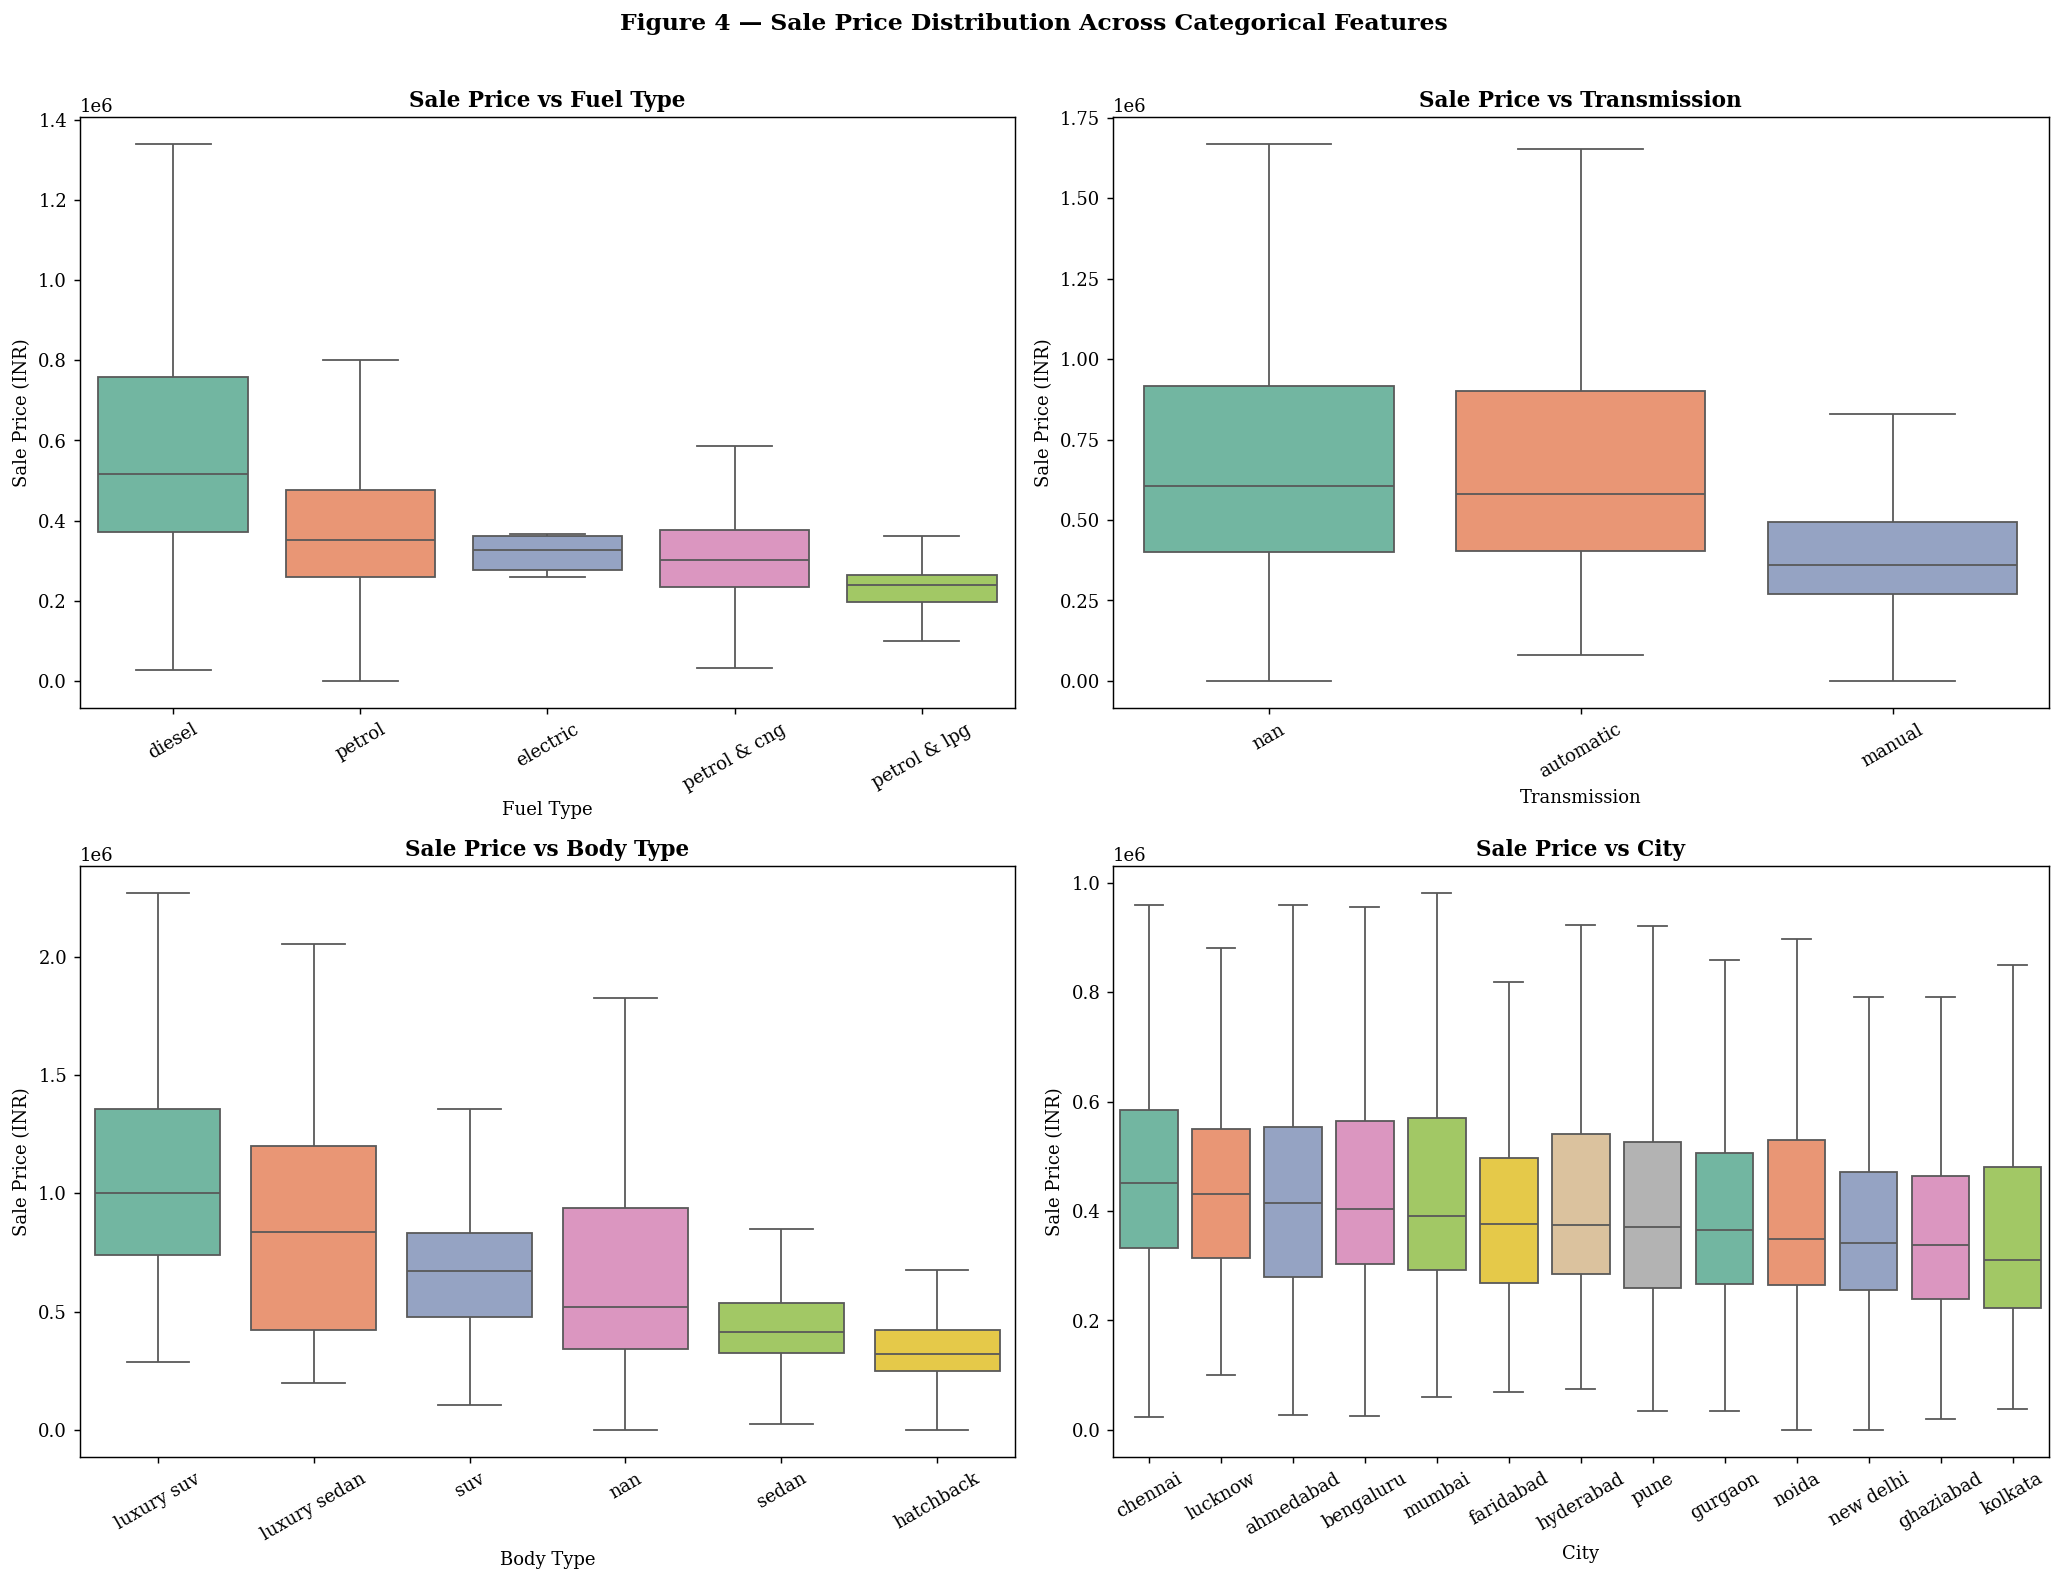

In [10]:
# Figure 4 — Sale price vs categorical features (Boxplots)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
cat_features = [('fuel_type', 'Fuel Type'),
                ('transmission', 'Transmission'),
                ('body_type', 'Body Type'),
                ('city', 'City')]

for ax, (col, label) in zip(axes.flatten(), cat_features):
    data_plot = pd.DataFrame({
        col: df_raw[col].astype(str),
        'sale_price': df_raw['sale_price']
    }).dropna()
    order = data_plot.groupby(col)['sale_price'].median()\
                     .sort_values(ascending=False).index
    sns.boxplot(data=data_plot, x=col, y='sale_price',
                order=order, ax=ax, palette='Set2', showfliers=False)
    ax.set_title(f'Sale Price vs {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Sale Price (INR)')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Figure 4 — Sale Price Distribution Across Categorical Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_boxplots_categorical.png', bbox_inches='tight')
plt.show()

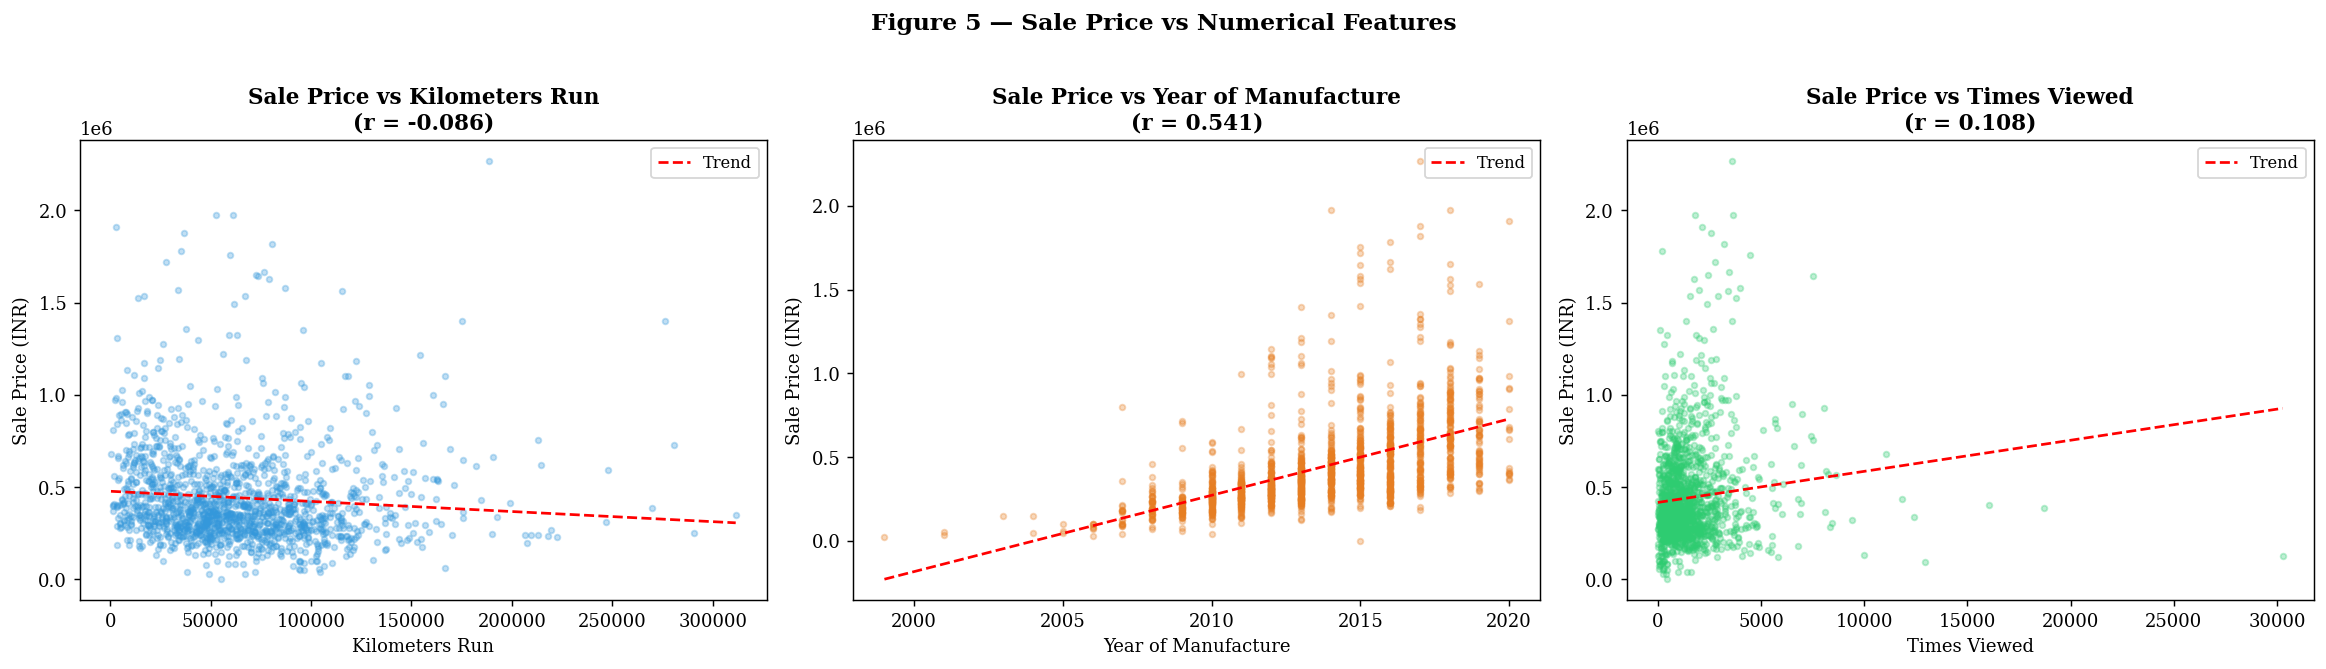

In [11]:
# Figure 5 — Sale price vs numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
num_features = [('kms_run', 'Kilometers Run'),
                ('yr_mfr', 'Year of Manufacture'),
                ('times_viewed', 'Times Viewed')]
colors = ['#3498db', '#e67e22', '#2ecc71']

for ax, (col, label), color in zip(axes, num_features, colors):
    sample = df_raw[[col, 'sale_price']].dropna().sample(
        min(1500, len(df_raw)), random_state=42)
    ax.scatter(sample[col], sample['sale_price'],
               alpha=0.3, s=10, color=color)
    z = np.polyfit(sample[col], sample['sale_price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[col].min(), sample[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')
    corr = sample[col].corr(sample['sale_price'])
    ax.set_title(f'Sale Price vs {label}\n(r = {corr:.3f})',
                 fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Sale Price (INR)')
    ax.legend(fontsize=9)

fig.suptitle('Figure 5 — Sale Price vs Numerical Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_scatter_numerical.png', bbox_inches='tight')
plt.show()

### 3. Preprocessing Pipeline

Steps applied in sequence:
1. Select 7 user-facing features + target
2. Normalize categorical text
3. Handle missing values (mode/median)
4. IQR outlier treatment on kms_run
5. Feature engineering (car_age, kms_per_year)
6. Label encoding
7. StandardScaler normalization
8. Train/test split (80/20)

In [12]:
# Step 1 — Select features
# These 7 features are what any seller can reasonably provide
# Leakage columns (broker_quote, original_price, etc.) are excluded

FEATURES    = ['yr_mfr', 'kms_run', 'fuel_type', 'city',
               'times_viewed', 'body_type', 'transmission', 'sale_price']
ENCODE_COLS = ['fuel_type', 'city', 'body_type', 'transmission']

df = df_raw[FEATURES].copy()

print("Selected features:", FEATURES[:-1])
print("Target variable: sale_price")
print(f"Working dataset shape: {df.shape}")

Selected features: ['yr_mfr', 'kms_run', 'fuel_type', 'city', 'times_viewed', 'body_type', 'transmission']
Target variable: sale_price
Working dataset shape: (7400, 8)


In [13]:
# Step 2 — Normalize categorical text
# Strips whitespace and lowercases all values
# Prevents 'Petrol' and 'petrol' from being treated as different categories

for col in ENCODE_COLS:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("Categorical columns normalized.")

Categorical columns normalized.


In [14]:
# Step 3 — Missing value imputation
# Mode for categorical: most frequent value is the best representative substitute
# Median for numerical: resistant to outlier distortion unlike the mean

for col in ENCODE_COLS:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in ['yr_mfr', 'kms_run', 'times_viewed', 'sale_price']:
    df[col] = df[col].fillna(df[col].median())

print(f"Missing values after imputation: {df.isnull().sum().sum()}")

Missing values after imputation: 0


In [15]:
# Step 4 — IQR outlier treatment on kms_run
# Lower bound = Q1 - 1.5 * IQR
# Upper bound = Q3 + 1.5 * IQR
# Values outside these bounds replaced with the column median
# Preserves sample size while neutralizing extreme values

Q1     = df['kms_run'].quantile(0.25)
Q3     = df['kms_run'].quantile(0.75)
IQR    = Q3 - Q1
lower  = Q1 - 1.5 * IQR
upper  = Q3 + 1.5 * IQR
median = df['kms_run'].median()

n_outliers = df[(df['kms_run'] < lower) | (df['kms_run'] > upper)].shape[0]
df['kms_run'] = df['kms_run'].apply(
    lambda x: median if x < lower or x > upper else x)

print(f"IQR Summary for kms_run:")
print(f"  Q1          : {Q1:,.0f} km")
print(f"  Q3          : {Q3:,.0f} km")
print(f"  IQR         : {IQR:,.0f} km")
print(f"  Lower Bound : {lower:,.0f} km")
print(f"  Upper Bound : {upper:,.0f} km")
print(f"  Outliers replaced: {n_outliers}")

IQR Summary for kms_run:
  Q1          : 31,885 km
  Q3          : 84,184 km
  IQR         : 52,299 km
  Lower Bound : -46,563 km
  Upper Bound : 162,632 km
  Outliers replaced: 178


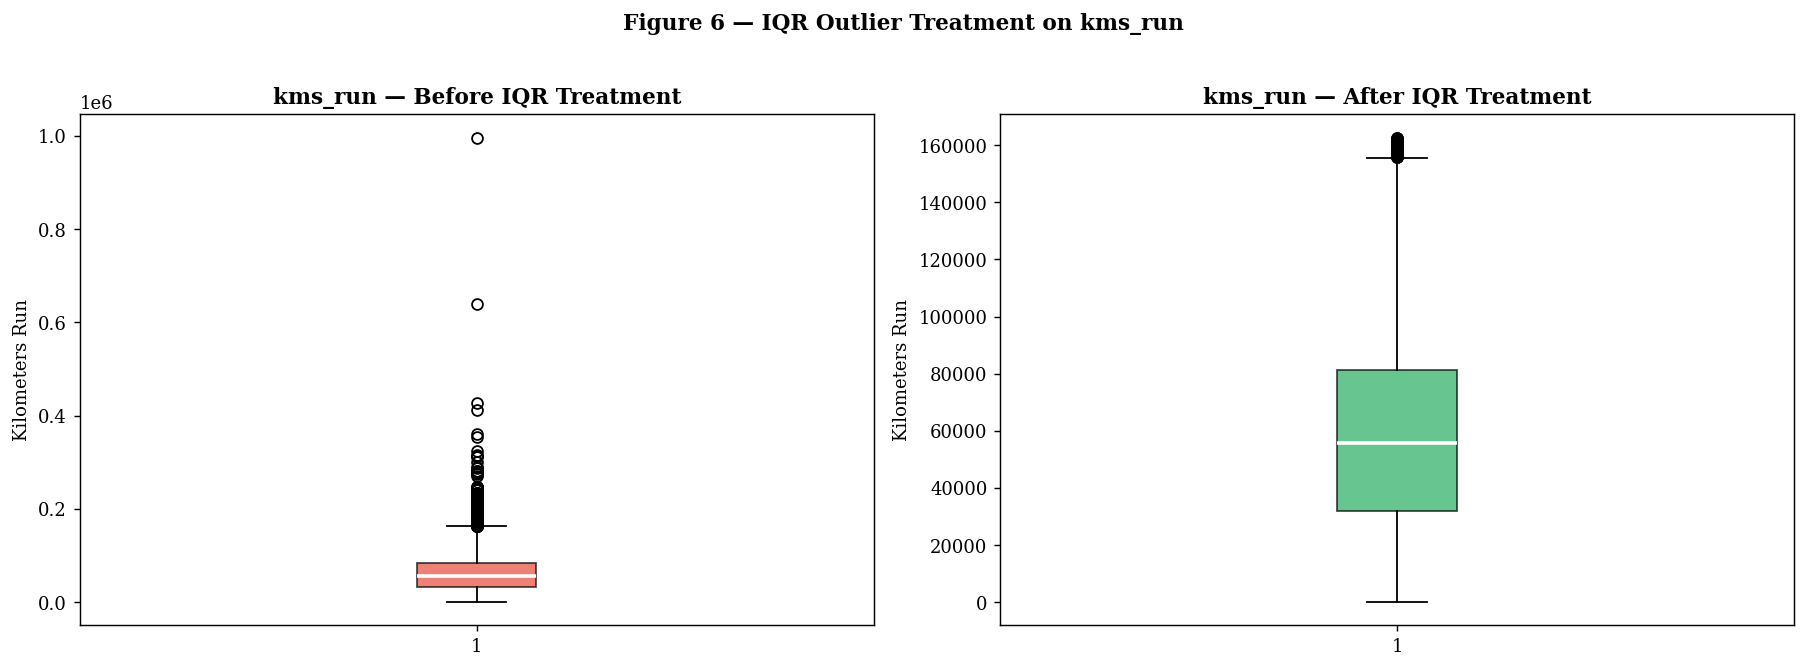

In [16]:
# Figure 6 — IQR Before/After
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_raw['kms_run'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#e74c3c', alpha=0.7),
                medianprops=dict(color='white', linewidth=2))
axes[0].set_title('kms_run — Before IQR Treatment', fontweight='bold')
axes[0].set_ylabel('Kilometers Run')

axes[1].boxplot(df['kms_run'], patch_artist=True,
                boxprops=dict(facecolor='#27ae60', alpha=0.7),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_title('kms_run — After IQR Treatment', fontweight='bold')
axes[1].set_ylabel('Kilometers Run')

fig.suptitle('Figure 6 — IQR Outlier Treatment on kms_run',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_iqr_treatment.png', bbox_inches='tight')
plt.show()

In [17]:
# Step 5 — Feature Engineering
# car_age: captures vehicle depreciation relative to age
# kms_per_year: captures usage intensity relative to age
# clip(lower=1) prevents division by zero for cars under 1 year old

current_year        = 2024
df['car_age']       = current_year - df['yr_mfr']
df['kms_per_year']  = df['kms_run'] / df['car_age'].clip(lower=1)
df.drop(columns=['yr_mfr'], inplace=True)

print("Feature engineering complete.")
print("New features: car_age, kms_per_year")
print(f"yr_mfr dropped. Updated shape: {df.shape}")

Feature engineering complete.
New features: car_age, kms_per_year
yr_mfr dropped. Updated shape: (7400, 9)


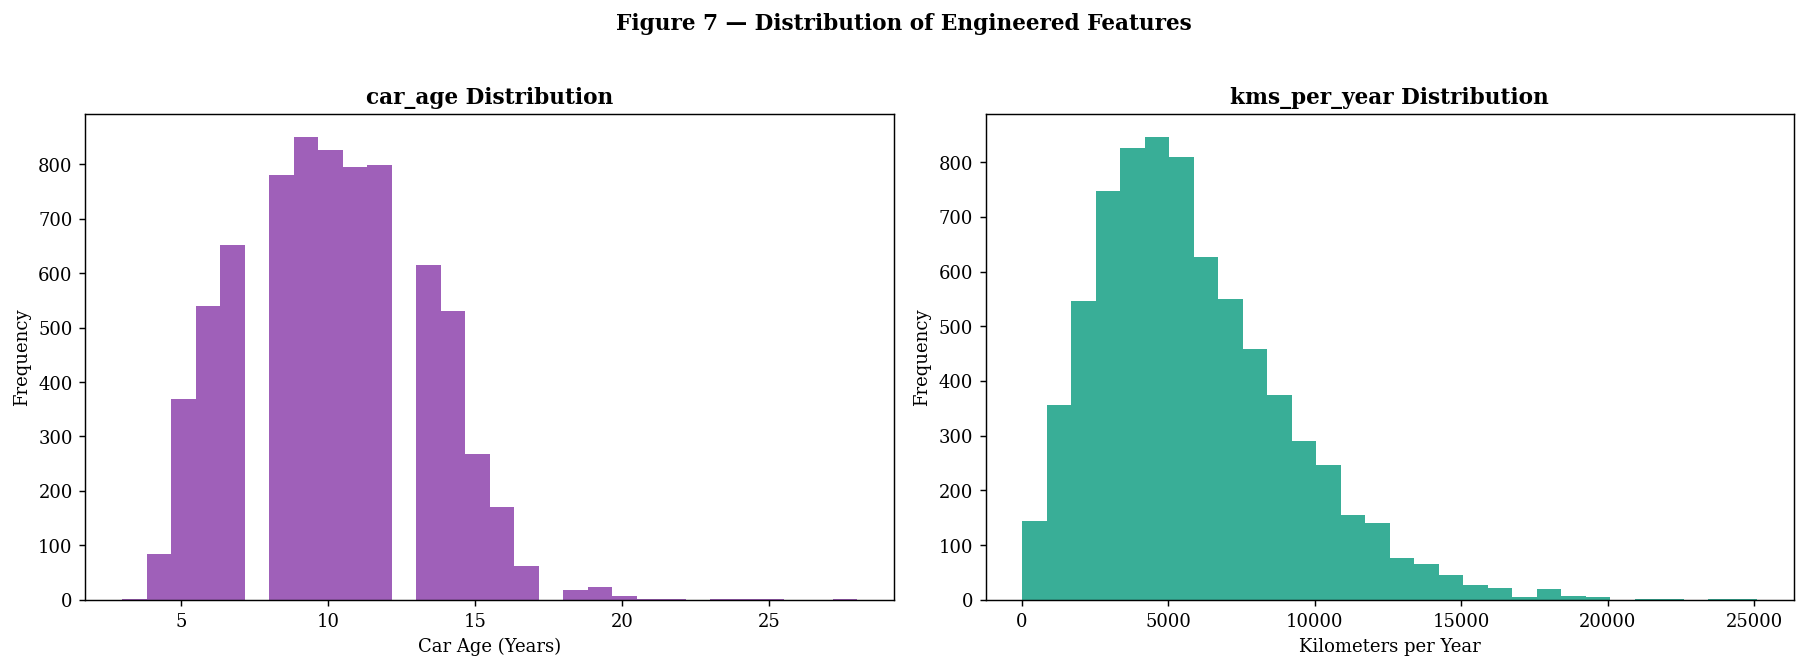

In [18]:
# Figure 7 — Engineered feature distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['car_age'], bins=30,
             color='#8e44ad', edgecolor='none', alpha=0.85)
axes[0].set_title('car_age Distribution', fontweight='bold')
axes[0].set_xlabel('Car Age (Years)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['kms_per_year'], bins=30,
             color='#16a085', edgecolor='none', alpha=0.85)
axes[1].set_title('kms_per_year Distribution', fontweight='bold')
axes[1].set_xlabel('Kilometers per Year')
axes[1].set_ylabel('Frequency')

fig.suptitle('Figure 7 — Distribution of Engineered Features',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_engineered_features.png', bbox_inches='tight')
plt.show()

In [19]:
# Step 6 — Label Encoding
# ML models require numerical inputs
# LabelEncoder assigns a unique integer to each category
# Encoders are saved so the same mapping applies to user inputs at inference

label_encoders = {}
for col in ENCODE_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {list(le.classes_)}")

print("\nEncoding complete.")

fuel_type: ['diesel', 'electric', 'petrol', 'petrol & cng', 'petrol & lpg']
city: ['ahmedabad', 'bengaluru', 'chennai', 'faridabad', 'ghaziabad', 'gurgaon', 'hyderabad', 'kolkata', 'lucknow', 'mumbai', 'new delhi', 'noida', 'pune']
body_type: ['hatchback', 'luxury sedan', 'luxury suv', 'nan', 'sedan', 'suv']
transmission: ['automatic', 'manual', 'nan']

Encoding complete.


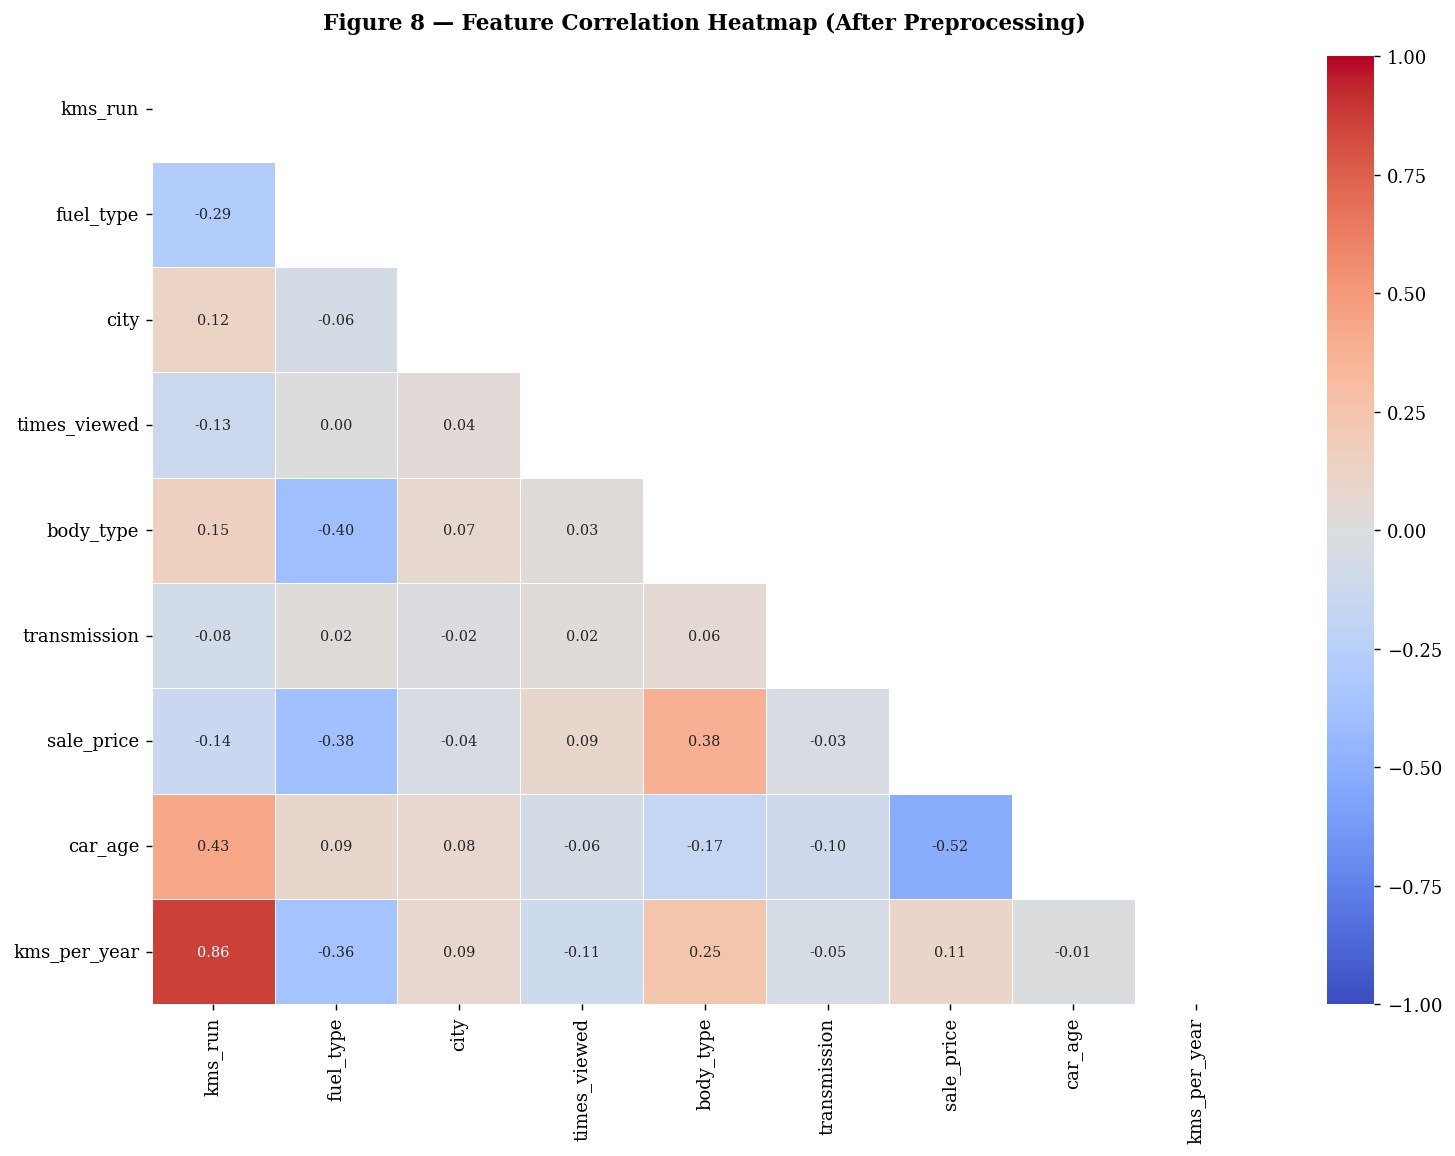


Correlation with sale_price:
sale_price      1.000000
body_type       0.378296
kms_per_year    0.107558
times_viewed    0.091579
transmission   -0.031817
city           -0.043063
kms_run        -0.142095
fuel_type      -0.384241
car_age        -0.518973
Name: sale_price, dtype: float64


In [20]:
# Figure 8 — Correlation heatmap after preprocessing
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.4, ax=ax,
            annot_kws={'size': 8}, vmin=-1, vmax=1, center=0)
ax.set_title('Figure 8 — Feature Correlation Heatmap (After Preprocessing)',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig8_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\nCorrelation with sale_price:")
print(df.corr()['sale_price'].sort_values(ascending=False))

In [21]:
# Step 7 — Feature Scaling
# StandardScaler: zero mean, unit variance
# Prevents large-range features (kms_run) from dominating small-range ones
# Fitted scaler is saved for consistent inference in the deployed app

feature_cols = [c for c in df.columns if c != 'sale_price']
X = df[feature_cols]
y = df['sale_price']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("StandardScaler applied.")
print(f"Feature columns: {feature_cols}")

StandardScaler applied.
Feature columns: ['kms_run', 'fuel_type', 'city', 'times_viewed', 'body_type', 'transmission', 'car_age', 'kms_per_year']


In [22]:
# Step 8 — Train/Test Split (80/20)
# random_state=42 ensures reproducibility
# 5,920 training samples | 1,480 test samples

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train/Test split complete.")
print(f"Training samples : {X_train.shape[0]:,} (80%)")
print(f"Testing samples  : {X_test.shape[0]:,}  (20%)")
print(f"Feature count    : {X_train.shape[1]}")

Train/Test split complete.
Training samples : 5,920 (80%)
Testing samples  : 1,480  (20%)
Feature count    : 8


In [23]:
# Export preprocessed artifacts
# These are loaded by model_selection.ipynb and hyperparameter_tuning.ipynb

os.makedirs('../models', exist_ok=True)

joblib.dump(scaler,        '../models/scaler.pkl')
joblib.dump(label_encoders,'../models/label_encoders.pkl')
joblib.dump(feature_cols,  '../models/feature_columns.pkl')

import numpy as np
np.save('../models/X_train.npy', X_train)
np.save('../models/X_test.npy',  X_test)
np.save('../models/y_train.npy', y_train.values)
np.save('../models/y_test.npy',  y_test.values)

print("Artifacts exported to ../models/")
print("  scaler.pkl")
print("  label_encoders.pkl")
print("  feature_columns.pkl")
print("  X_train.npy, X_test.npy")
print("  y_train.npy, y_test.npy")

Artifacts exported to ../models/
  scaler.pkl
  label_encoders.pkl
  feature_columns.pkl
  X_train.npy, X_test.npy
  y_train.npy, y_test.npy


### Preprocessing Summary

| Step | Method | Output |
|---|---|---|
| Features Selected | 7 user-facing + target | 8 columns |
| Missing Values | Mode (categorical), Median (numerical) | 0 missing |
| Outlier Treatment | IQR on kms_run | Outliers replaced with median |
| Feature Engineering | car_age, kms_per_year | 2 new features |
| Encoding | LabelEncoder x4 | Integer codes |
| Scaling | StandardScaler | Mean=0, Std=1 |
| Train/Test Split | 80/20, random_state=42 | 5,920 / 1,480 |

**Final feature set:**
`kms_run, fuel_type, city, times_viewed, body_type,
transmission, car_age, kms_per_year`

**Target variable:** `sale_price` (INR)